---
numbering:
  enumerator: "14.%s"
  equation:
    template: "%s"  
---

(chap_ensemble)=
# Ensemble models

Let us be honest. When facing a prediction task, it is not obvious to determine the best choice between ML tools: penalized regressions, tree methods, neural networks, SVMs, etc. A natural and tempting alternative is to **combine** several algorithms (or the predictions that result from them) to try to extract value out of each engine (or learner). This intention is not new and contributions towards this goal go back at least to @bates1969combination (for the purpose of passenger flow forecasting).

Below, we outline a few books on the topic of ensembles. The latter have many names and synonyms, such as **forecast aggregation**, **model averaging**, **mixture of experts** or **prediction combination**. The first four references below are monographs, while the last two are compilations of contributions:

- @zhou2012ensemble: a very didactic book that covers the main ideas of ensembles;  
- @schapire2012boosting: the main reference for boosting (and hence, ensembling) with many theoretical results and thus strong mathematical groundings;  
- @seni2010ensemble: an introduction dedicated to tree methods mainly;  
- @claeskens2008model: an overview of model selection techniques with a few chapters focused on model averaging;  
- @zhang2012ensemble: a collection of thematic chapters on ensemble learning;  
- @okun2011ensembles: examples of applications of ensembles.

In this chapter, we cover the basic ideas and concepts behind the notion of ensembles. We refer to the above books for deeper treatments on the topic. We underline that several ensemble methods have already been mentioned and covered earlier, notably in Chapter [](#chap_trees). Indeed, random forests and boosted trees are examples of ensembles. Hence, other early articles on the combination of learners are @schapire1990strength, @jacobs1991adaptive (for neural networks particularly), and @freund1997decision. Ensembles can for instance be used to aggregate models that are built on different datasets [@pesaran2011forecast], and can be made time-dependent [@sun2020time]. For a theoretical view on ensembles, we refer to @peng2022improvability and @razin2020drowning (Bayesian perspective). Forecast combinations for returns are investigated in @cheng2022stock and widely reviewed by @wang2022forecast - see also @scholz2022forecast for a contrarian take (ensembles don't always work well). Finally, perspectives linked to asset pricing and factor modelling are provided in @gospodinov2020generalized, @de2020subsampled (subsampling and forecast aggregation) and @remlinger2023expert (Bernstein Online Aggregation). 

From the standpoint of asset pricing anomalies, @reschenhofer2024combining discusses the combination of several factors: this allows to lower volatility.

## Linear ensembles

### Principles

In this chapter we adopt the following notations. We work with $M$ models where $\tilde{y}_{i,m}$ is the prediction of model $m$ for instance $i$ and errors $\epsilon_{i,m}=y_i-\tilde{y}_{i,m}$ are stacked into a $(I\times M)$ matrix $\textbf{E}$. A linear combination of models has sample errors equal to $\textbf{Ew}$, where $\textbf{w}=w_m$ are the weights assigned to each model and we assume $\textbf{w}'\textbf{1}_M=1$. Minimizing the total (squared) error is thus a simple quadratic program with unique constraint. The Lagrange function is $L(\textbf{w})=\textbf{w}'\textbf{E}'\textbf{E}\textbf{w}-\lambda (\textbf{w}'\textbf{1}_M-1)$ and hence
$$\frac{\partial}{\partial \textbf{w}}L(\textbf{w})=\textbf{E}'\textbf{E}\textbf{w}-\lambda \textbf{1}_M=0 \quad \Leftrightarrow \quad \textbf{w}=\lambda(\textbf{E}'\textbf{E})^{-1}\textbf{1}_M,$$

and the constraint imposes $\textbf{w}^*=\frac{(\textbf{E}'\textbf{E})^{-1}\textbf{1}_M}{(\textbf{1}_M'\textbf{E}'\textbf{E})^{-1}\textbf{1}_M}$. This form is similar to that of minimum variance portfolios.  If errors are unbiased ($\textbf{1}_I'\textbf{E}=\textbf{0}_M'$), then $\textbf{E}'\textbf{E}$ is the covariance matrix of errors.  

This expression shows an important feature of optimized linear ensembles: they can only add value if the models tell different stories. If two models are redundant, $\textbf{E}'\textbf{E}$ will be close to singular and $\textbf{w}^*$ will arbitrage one against the other in a spurious fashion. This is the exact same problem as when mean-variance portfolios are constituted with highly correlated assets: in this case, diversification fails because when things go wrong, all assets go down. Another problem arises when the number of observations is too small compared to the number of assets so that the covariance matrix of returns is singular. This is not an issue for ensembles because the number of observations will usually be much larger than the number of models ($I>>M$).

In the limit when correlations increase to one, the above formulation becomes highly unstable and ensembles cannot be trusted. One heuristic way to see this is when $M=2$ and 
$$\textbf{E}'\textbf{E}=\left[
\begin{array}{cc} \sigma_1^2 & \rho\sigma_1\sigma_2 \\
\rho\sigma_1\sigma_2 & \sigma_2^2 \\
\end{array}
\right] \quad \Leftrightarrow  \quad 
(\textbf{E}'\textbf{E})^{-1}=\frac{1}{1-\rho^2}\left[
\begin{array}{cc} \sigma_1^{-2} & -\rho(\sigma_1\sigma_2)^{-1} \\
-\rho(\sigma_1\sigma_2)^{-1} & \sigma_2^{-2} \\
\end{array}
\right]$$

so that when $\rho \rightarrow 1$, the model with the smallest errors (minimum $\sigma_i^2$) will see its weight increasing towards infinity while the other model will have a similarly large **negative weight**: the model arbitrages between two highly correlated variables. This seems like a very bad idea. 

There is another illustration of the issues caused by correlations. Let's assume we face $M$ correlated errors $\epsilon_m$ with pairwise correlation $\rho$, zero mean and variance $\sigma^2$. The variance of errors is 
\begin{align*}
\mathbb{E}\left[\frac{1}{M}\sum_{m=1}^M \epsilon_m^2 \right]&=\frac{1}{M^2}\left[\sum_{m=1}^M\epsilon_m^2+\sum_{m\neq n}\epsilon_n\epsilon_m\right] \\
&=\frac{\sigma^2}{M}+\frac{1}{M^2}\sum_{n\neq m} \rho \sigma^2 \\
& =\rho \sigma^2 +\frac{\sigma^2(1-\rho)}{M}
\end{align*}
where while the second term converges to zero as $M$ increases, the first term remains and is **linearly increasing** with $\rho$. In passing, because variances are always positive, this result implies that the common pairwise correlation between $M$ variables is bounded below by $-(M-1)^{-1}$. This result is interesting but rarely found in textbooks.

One improvement proposed to circumvent the trouble caused by correlations, advocated in a seminal publication [@breiman1996stacked], is to enforce positivity constraints on the weights and solve

$$\underset{\textbf{w}}{\text{argmin}} \ \textbf{w}'\textbf{E}'\textbf{E}\textbf{w} , \quad \text{s.t.} \quad \left\{ 
\begin{array}{l} \textbf{w}'\textbf{1}_M=1 \\ w_m \ge 0 \quad \forall m \end{array}\right. .$$

Mechanically, if several models are highly correlated, the constraint will impose that only one of them will have a nonzero weight. If there are many models, then just a few of them will be selected by the minimization program. In the context of portfolio optimization, @jagannathan2003risk have shown the counter-intuitive benefits of constraints in the construction of mean-variance allocations. In our setting, the constraint will similarly help discriminate wisely among the 'best' models.

In the literature, forecast combination and model averaging (which are synonyms of ensembles) have been tested on stock markets as early as in @von1972probabilistic. Surprisingly, the articles were not published in Finance journals but rather in fields such as Management (@virtanen1987forecasting, @wang2012stock), Economics and Econometrics (@donaldson1996forecast, @clark2009improving, @mascio2020market), Operations Research (@huang2005forecasting, @leung2001using, and @bonaccolto2019developing), and Computer Science (@harrald1997evolving, @hassan2007fusion).


In the general forecasting literature, many alternative (refined) methods for combining forecasts have been studied. Trimmed opinion pools [@grushka2016ensembles] compute averages over the predictions that are not too extreme (or not too noisy, see @chiang2021modeling). Ensembles with weights that depend on previous past errors are developed in @pike2020combining. We refer to @gaba2017combining for a more exhaustive list of combinations as well as for an empirical study of their respective efficiency. Finally, for a theoretical discussion on model averaging versus model selection, we point to @peng2022improvability.
Overall, findings are mixed and the heuristic simple average is, as usual, hard to beat (see, e.g., @genre2013combining).

### Example

In order to build an ensemble, we must gather the predictions and the corresponding errors into the $\textbf{E}$ matrix. We will work with 5 models that were trained in the previous chapters: penalized regression, simple tree, random forest, xgboost and feed-forward neural network. The training errors have zero means, hence $\textbf{E}'\textbf{E}$ is the covariance matrix of errors between models.

In [ ]:
%config InlineBackend.figure_formats = ['png', 'pdf']


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

import os
os.environ["KERAS_BACKEND"] = "jax"

import keras
from keras import layers
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from scipy.optimize import minimize
import pandas_datareader.data as web
from datetime import datetime

from data_build import generate_data
data_ml, features, features_short, returns, stock_ids, stock_ids_short = generate_data()
features_short = ["Div_yld", "EPS", "size_avg_252d", "mom_252", "OCF_Growth_1Y", "PB", "vol_252"]
separation_date = "2017-01-15"

# Data preparation
data_ml_clean = data_ml.dropna()
training_sample = data_ml_clean[data_ml['date'] <= separation_date]
testing_sample = data_ml_clean[data_ml['date'] > separation_date]

In [2]:
# Train models from previous chapters
# 1. Penalized regression
x_penalized_train = training_sample[features].values
y_train = training_sample['R1M'].values
fit_pen_pred = ElasticNet(alpha=0.1, l1_ratio=0.1, fit_intercept=True)
fit_pen_pred.fit(x_penalized_train, y_train)

# 2. Simple tree
fit_tree = DecisionTreeRegressor(
    min_samples_leaf=1500,
    min_samples_split=4000,
    ccp_alpha=0.0001,
    max_depth=5
)
fit_tree.fit(training_sample[features], y_train)

# 3. Random forest
np.random.seed(42)
fit_RF = RandomForestRegressor(
    n_estimators=40,
    max_samples=10000,
    bootstrap=True,
    min_samples_leaf=250,
    max_features=30,
    random_state=42
)
fit_RF.fit(training_sample[features], y_train)

# 4. XGBoost (on extreme values)
q20 = training_sample['R1M'].quantile(0.2)
q80 = training_sample['R1M'].quantile(0.8)
train_extreme = training_sample[
    (training_sample['R1M'] < q20) | (training_sample['R1M'] > q80)
]
train_features_xgb = train_extreme[features].values
train_label_xgb = train_extreme['R1M'].values
train_matrix_xgb = xgb.DMatrix(data=train_features_xgb, label=train_label_xgb)
params_xgb = {
    'eta': 0.4,
    'objective': 'reg:squarederror',
    'max_depth': 4,
    'verbosity': 0
}
fit_xgb = xgb.train(params=params_xgb, dtrain=train_matrix_xgb, num_boost_round=18)

# 5. Neural network
NN_train_features = training_sample[features].values
NN_train_labels = training_sample['R1M'].values
model = keras.Sequential([
    layers.Dense(units=16, activation='relu', input_shape=(NN_train_features.shape[1],)),
    layers.Dense(units=8, activation='tanh'),
    layers.Dense(units=1)
])
model.compile(loss='mean_squared_error', optimizer='rmsprop', metrics=['mean_absolute_error'])
model.fit(NN_train_features, NN_train_labels, epochs=10, batch_size=512, verbose=0)

In [3]:
# Compute training errors for each model
x_penalized_test = testing_sample[features].values
xgb_test = xgb.DMatrix(testing_sample[features].values)
NN_test_features = testing_sample[features].values

err_pen_train = fit_pen_pred.predict(x_penalized_train) - training_sample['R1M'].values      # Reg.
err_tree_train = fit_tree.predict(training_sample[features]) - training_sample['R1M'].values # Tree
err_RF_train = fit_RF.predict(training_sample[features]) - training_sample['R1M'].values     # RF
err_XGB_train = fit_xgb.predict(xgb.DMatrix(training_sample[features].values)) - training_sample['R1M'].values  # XGBoost
err_NN_train = model.predict(NN_train_features, verbose=0).flatten() - training_sample['R1M'].values  # NN

# E matrix
E = np.column_stack([err_pen_train, err_tree_train, err_RF_train, err_XGB_train, err_NN_train])
col_names = ["Pen_reg", "Tree", "RF", "XGB", "NN"]

# Correlation matrix
E_df = pd.DataFrame(E, columns=col_names)
print("Correlation matrix of training errors:")
print(E_df.corr().round(3))

Correlation matrix of training errors:
         Pen_reg   Tree     RF    XGB     NN
Pen_reg    1.000  0.264  0.898  0.192  0.319
Tree       0.264  1.000  0.328  0.047  0.143
RF         0.898  0.328  1.000  0.031  0.327
XGB        0.192  0.047  0.031  1.000  0.031
NN         0.319  0.143  0.327  0.031  1.000


As is shown by the correlation matrix, the models fail to generate heterogeneity in their predictions. The minimum correlation (though above 95%!) is obtained by the boosted tree models. Below, we compare the training accuracy of models by computing the average absolute value of errors.

In [4]:
# Mean absolute error for columns of E
print("Mean absolute error by model:")
print(pd.Series(np.abs(E).mean(axis=0), index=col_names).round(5))

Mean absolute error by model:
Pen_reg    0.07472
Tree       0.02103
RF         0.03272
XGB        0.03554
NN         0.02543
dtype: float64


The best performing ML engine is the random forest. The boosted tree model is the worst, by far. Below, we compute the optimal (non-constrained) weights for the combination of models.

In [5]:
# Optimal weights
ones = np.ones(5)
EtE = E.T @ E
EtE_inv = np.linalg.inv(EtE)
w_ensemble = EtE_inv @ ones
w_ensemble = w_ensemble / w_ensemble.sum()
print("Optimal unconstrained weights:")
print(pd.Series(w_ensemble.round(3), index=col_names))

Optimal unconstrained weights:
Pen_reg   -0.114
Tree       0.169
RF         0.140
XGB        0.260
NN         0.545
dtype: float64


Because of the high correlations, the optimal weights are not balanced and diversified: they load heavily on the random forest learner (best in sample model) and 'short' a few models in order to compensate. As one could expect, the model with the largest negative weights (Pen_reg) has a very high correlation with the random forest algorithm (0.997).

Note that the weights are of course computed with **training errors**. The optimal combination is then tested on the testing sample. Below, we compute out-of-sample (testing) errors and their average absolute value.

In [6]:
# Testing errors
err_pen_test = fit_pen_pred.predict(x_penalized_test) - testing_sample['R1M'].values      # Reg.
err_tree_test = fit_tree.predict(testing_sample[features]) - testing_sample['R1M'].values  # Tree
err_RF_test = fit_RF.predict(testing_sample[features]) - testing_sample['R1M'].values      # RF
err_XGB_test = fit_xgb.predict(xgb_test) - testing_sample['R1M'].values                    # XGBoost
err_NN_test = model.predict(NN_test_features, verbose=0).flatten() - testing_sample['R1M'].values  # NN

# E_test matrix
E_test = np.column_stack([err_pen_test, err_tree_test, err_RF_test, err_XGB_test, err_NN_test])
E_test_df = pd.DataFrame(E_test, columns=col_names)

# Mean absolute error for testing
print("Mean absolute error by model (testing):")
print(pd.Series(np.abs(E_test).mean(axis=0), index=col_names).round(5))

Mean absolute error by model (testing):
Pen_reg    0.08322
Tree       0.02214
RF         0.03742
XGB        0.03345
NN         0.02501
dtype: float64


The boosted tree model is still the worst performing algorithm while the simple models (regression and simple tree) are the ones that fare the best. The most naive combination is the simple average of model and predictions.

In [7]:
# Equally weighted combination
err_EW_test = E_test.mean(axis=1)
print(f"Mean absolute error (EW combination): {np.abs(err_EW_test).mean():.5f}")

Mean absolute error (EW combination): 0.02839


Because the errors are very correlated, the equally weighted combination of forecasts yields an average error which lies 'in the middle' of individual errors. The diversification benefits are too small. Let us now test the 'optimal' combination $\textbf{w}^*=\frac{(\textbf{E}'\textbf{E})^{-1}\textbf{1}_M}{(\textbf{1}_M'\textbf{E}'\textbf{E})^{-1}\textbf{1}_M}$.

In [8]:
# Optimal unconstrained combination
err_opt_test = E_test @ w_ensemble
print(f"Mean absolute error (optimal combination): {np.abs(err_opt_test).mean():.5f}")

Mean absolute error (optimal combination): 0.01079


Again, the result is disappointing because of the lack of diversification across models. The correlations between errors are high not only on the training sample, but also on the testing sample, as shown below.

In [9]:
# Correlation matrix of testing errors
print("Correlation matrix of testing errors:")
print(E_test_df.corr().round(3))

Correlation matrix of testing errors:
         Pen_reg   Tree     RF    XGB     NN
Pen_reg    1.000  0.265  0.909  0.159  0.321
Tree       0.265  1.000  0.326  0.042  0.127
RF         0.909  0.326  1.000  0.030  0.324
XGB        0.159  0.042  0.030  1.000  0.052
NN         0.321  0.127  0.324  0.052  1.000


The leverage from the optimal solution only exacerbates the problem and underperforms the heuristic uniform combination. We end this section with the constrained formulation of @breiman1996stacked using quadratic programming. If we write $\mathbf{\Sigma}$ for the covariance matrix of errors, we seek
$$\mathbf{w}^*=\underset{\mathbf{w}}{\text{argmin}} \ \mathbf{w}'\mathbf{\Sigma}\mathbf{w}, \quad \mathbf{1}'\mathbf{w}=1, \quad w_i\ge 0,$$
The constraints will be handled as:

$$\mathbf{A} \mathbf{w}= \begin{bmatrix} 
1 & 1 & 1 \\
1 & 0 & 0\\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix} \mathbf{w} \hspace{9mm} \text{ compared to} \hspace{9mm} \mathbf{b}=\begin{bmatrix} 1 \\ 0 \\ 0 \\ 0 \end{bmatrix},  $$

where the first line will be an equality (weights sum to one) and the last three will be inequalities (weights are all positive).

In [10]:
from scipy.optimize import minimize

Sigma = E.T @ E                         # Unscaled covariance matrix
nb_mods = Sigma.shape[0]                # Number of models

# Objective function: w' Sigma w
def objective(w):
    return w @ Sigma @ w

# Constraints
constraints = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}  # Weights sum to 1
]

# Bounds: all weights >= 0
bounds = [(0, None) for _ in range(nb_mods)]

# Initial guess
w0 = np.ones(nb_mods) / nb_mods

# Solve
result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
w_const = result.x

print("Constrained optimal weights:")
print(pd.Series(w_const.round(3), index=col_names))

Constrained optimal weights:
Pen_reg    0.000
Tree       0.202
RF         0.000
XGB        0.244
NN         0.554
dtype: float64


Compared to the unconstrained solution, the weights are sparse and concentrated in one or two models, usually those with small training sample errors.

## Stacked ensembles

### Two-stage training

**Stacked ensembles** are a natural generalization of linear ensembles. The idea of generalizing linear ensembles goes back at least to @wolpert1992stacked. In the general case, the training is performed in two stages. The first stage is the simple one, whereby the $M$ models are trained independently, yielding the predictions $\tilde{y}_{i,m}$ for instance $i$ and model $m$. The second step is to consider the output of the trained models as input for a new level of machine learning optimization. The second level predictions are $\breve{y}_i=h(\tilde{y}_{i,1},\dots,\tilde{y}_{i,M})$, where $h$ is a new learner (see Figure below). Linear ensembles are of course stacked ensembles in which the second layer is a linear regression.  

The same techniques are then applied to minimize the error between the true values $y_i$ and the predicted ones $\breve{y}_i$.

```{figure} images/stack.png
:name: fig-stackscheme
:align: center
Scheme of stacked ensembles.
```

### Code and results

Below, we create a low-dimensional neural network which takes in the individual predictions of each model and compiles them into a synthetic forecast.

In [11]:
# Define the stacked neural network
model_stack = keras.Sequential([
    layers.Dense(units=8, activation='relu', input_shape=(nb_mods,)),
    layers.Dense(units=4, activation='tanh'),
    layers.Dense(units=1)
])

The configuration is very simple. We do not include any optional arguments and hence the model is likely to overfit. As we seek to predict returns, the loss function is the standard $L^2$ norm.

In [12]:
# Model specification
model_stack.compile(
    loss='mean_squared_error',
    optimizer='rmsprop',
    metrics=['mean_absolute_error']
)
model_stack.summary()

Model: "sequential_1"


+---------------------------------+------------------------+---------------+
| Layer (type)                    | Output Shape           |       Param # |
+---------------------------------+------------------------+---------------+
| dense_3 (Dense)                 | (None, 8)              |            48 |
+---------------------------------+------------------------+---------------+
| dense_4 (Dense)                 | (None, 4)              |            36 |
+---------------------------------+------------------------+---------------+
| dense_5 (Dense)                 | (None, 1)              |             5 |
+---------------------------------+------------------------+---------------+


 Total params: 89 (356.00 B)


 Trainable params: 89 (356.00 B)


 Non-trainable params: 0 (0.00 B)


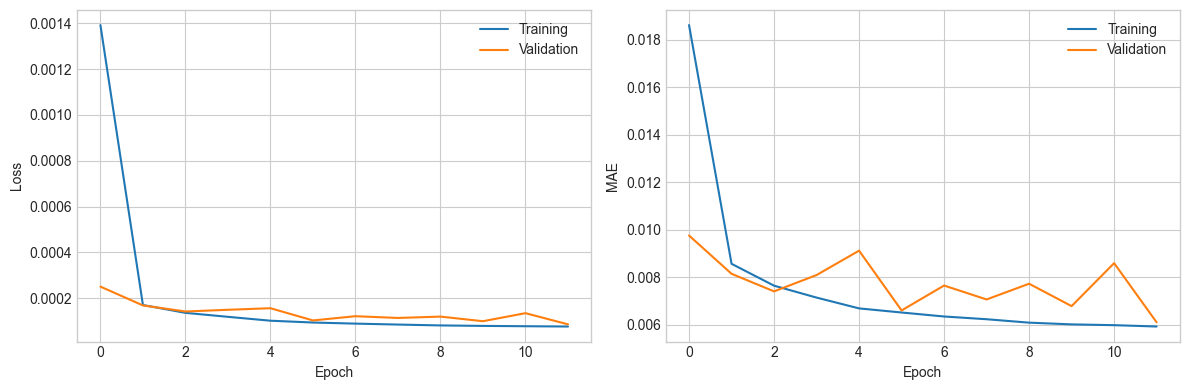

In [13]:
#| label: fig-stackNN2
#| fig-cap: "Training metrics for the ensemble model."

# Prepare predictions as features
y_tilde = E + np.tile(training_sample['R1M'].values.reshape(-1, 1), nb_mods)     # Train preds
y_test_stack = E_test + np.tile(testing_sample['R1M'].values.reshape(-1, 1), nb_mods)  # Testing

# Train the stacked model
fit_NN_stack = model_stack.fit(
    y_tilde, training_sample['R1M'].values,    # Train features & labels
    epochs=12, batch_size=512, verbose=0,       # Train parameters (quiet: keeps the
                                                # figure caption free of the training log)
    validation_data=(y_test_stack, testing_sample['R1M'].values)  # Validation
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fit_NN_stack.history['loss'], label='Training')
axes[0].plot(fit_NN_stack.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].plot(fit_NN_stack.history['mean_absolute_error'], label='Training')
axes[1].plot(fit_NN_stack.history['val_mean_absolute_error'], label='Validation')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE'); axes[1].legend()
plt.tight_layout(); plt.show()

The performance of the ensemble is again disappointing: the learning curve is flat in the figure above, hence the rounds of back-propagation are useless. The training adds little value which means that the new overarching layer of ML does not enhance the original predictions. Again, this is because all ML engines seem to be capturing the same patterns and both their linear and non-linear combinations fail to improve their performance.

## Extensions
### Exogenous variables

In a financial context, macro-economic indicators could add value to the process. It is possible that some models perform better under certain conditions and exogenous predictors can help introduce a flavor of **economic-driven conditionality** in the predictions. 

Adding macro-variables to the set of predictors (here, predictions) $\tilde{y}_{i,m}$ could seem like one way to achieve this. However, this would amount to mix predicted values with (possibly scaled) economic indicators and that would not make much sense.

One alternative outside the perimeter of ensembles is to train simple trees on a set of macro-economic indicators. If the labels are the (possibly absolute) errors stemming from the original predictions, then the trees will create clusters of homogeneous error values. This will hint towards which conditions lead to the best and worst forecasts. 
We test this idea below, using aggregate data from the Federal Reserve of Saint Louis. A simple downloading function is available via pandas-datareader. We download and format the data in the next chunk. CPIAUCSL is a code for consumer price index and T10Y2YM is a code for the term spread (10Y minus 2Y).

In [14]:
# Download FRED data
start_date = datetime(2000, 1, 1)
end_date = datetime(2020, 12, 31)

cpi = web.DataReader('CPIAUCSL', 'fred', start_date, end_date)
ts = web.DataReader('T10Y2YM', 'fred', start_date, end_date)

# Compute inflation
cpi['inflation'] = cpi['CPIAUCSL'].pct_change()
ts.columns = ['termspread']

# Create ensemble data with macro variables
ens_data = testing_sample[['date']].copy()
ens_data['err_NN_test'] = err_NN_test
ens_data['month_start'] = pd.to_datetime(ens_data['date']).dt.to_period('M').dt.to_timestamp()

# Merge with macro data
cpi_monthly = cpi[['inflation']].reset_index()
cpi_monthly.columns = ['month_start', 'inflation']
ts_monthly = ts.reset_index()
ts_monthly.columns = ['month_start', 'termspread']

ens_data = ens_data.merge(cpi_monthly, on='month_start', how='left')
ens_data = ens_data.merge(ts_monthly, on='month_start', how='left')

print(ens_data.head())

        date  err_NN_test month_start  inflation  termspread
0 2017-01-31    -0.005671  2017-01-01   0.004043        1.22
1 2017-02-28    -0.015538  2017-02-01   0.001593        1.22
2 2017-03-31    -0.012140  2017-03-01  -0.000467        1.17
3 2017-04-30    -0.016495  2017-04-01   0.001234        1.06
4 2017-05-31    -0.020685  2017-05-01  -0.000774        1.00


We can now build a tree that tries to explain the accuracy of models as a function of macro-variables.

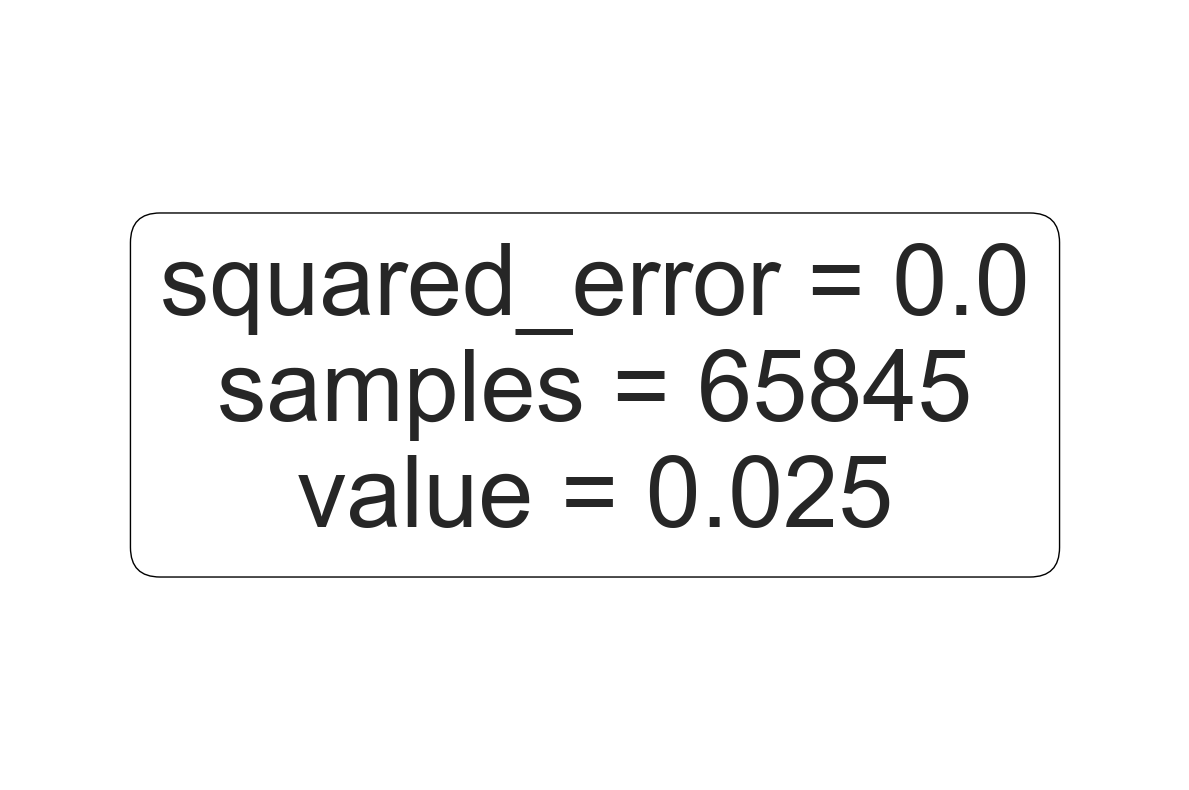

In [15]:
#| label: fig-ensfred2
#| fig-cap: "Conditional performance of a ML engine."

from sklearn.tree import DecisionTreeRegressor, plot_tree

# Prepare data for tree
ens_data_clean = ens_data.dropna(subset=['inflation', 'termspread'])
X_macro = ens_data_clean[['inflation', 'termspread']]
y_macro = np.abs(ens_data_clean['err_NN_test'])

# Fit tree
fit_ens = DecisionTreeRegressor(ccp_alpha=0.001, max_depth=3)
fit_ens.fit(X_macro, y_macro)

# Plot tree
plt.figure(figsize=(12, 8))
plot_tree(fit_ens, feature_names=['inflation', 'termspread'], filled=True, rounded=True)
plt.tight_layout()
plt.show()

The tree creates clusters which have homogeneous values of absolute errors. One big cluster gathers 92% of predictions (the left one) and is the one with the smallest average. It corresponds to the periods when the term spread is above 0.29 (in percentage points). The other two groups (when the term spread is below 0.29%) are determined according to the level of inflation. If the latter is positive, then the average absolute error is 7%, if not, it is 12%. This last number, the highest of the three clusters, indicates that when the term spread is low and the inflation negative, the model's predictions are not trustworthy because their errors have a magnitude twice as large as in other periods. Under these circumstances (which seem to be linked to a dire economic environment), it may be wiser not to use ML-based forecasts.

### Shrinking inter-model correlations

As shown earlier in this chapter, one major problem with ensembles arises when the first layer of predictions is highly correlated. In this case, ensembles are pretty much useless. There are several tricks that can help reduce this correlation, but the simplest and best is probably to alter training samples. If algorithms do not see the same data, they will probably infer different patterns.

There are several ways to split the training data so as to build different subsets of training samples. The first dichotomy is between random versus deterministic splits. Random splits are easy and require only the target sample size to be fixed. Note that the training samples can be overlapping as long as the overlap is not too large. Hence if the original training sample has $I$ instance and the ensemble requires $M$ models, then a subsample size of $\lfloor I/M \rfloor$ may be too conservative especially if the training sample is not very large. In this case $\lfloor I/\sqrt{M} \rfloor$ may be a better alternative. Random forests are one example of ensembles built in random training samples.

One advantage of deterministic splits is that they are easy to reproduce and their outcome does not depend on the random seed. By the nature of factor-based training samples, the second splitting dichotomy is between time and assets. A split within assets is straightforward: each model is trained on a different set of stocks. Note that the choices of sets can be random, or dictated by some factor-based criterion: size, momentum, book-to-market ratio, etc. 

A split in dates requires other decisions: is the data split in large blocks (like years) and each model gets a block, which may stand for one particular kind of market condition? Or are the training dates divided more regularly? For instance, if there are 12 models in the ensemble, each model can be trained on data from a given month (e.g., January for the first models, February for the second, etc.).

Below, we train four models on four different years to see if this helps reduce the inter-model correlations. This process is a bit lengthy because the samples and models need to be all redefined. We start by creating the four training samples. The third model works on the small subset of features, hence the sample is smaller.

In [16]:
# Create year-specific training samples
training_sample_2007 = training_sample[
    (training_sample['date'] > "2006-12-31") & (training_sample['date'] < "2008-01-01")
]
training_sample_2009 = training_sample[
    (training_sample['date'] > "2008-12-31") & (training_sample['date'] < "2010-01-01")
]
training_sample_2011 = training_sample[
    (training_sample['date'] > "2010-12-31") & (training_sample['date'] < "2012-01-01")
][['date'] + features_short + ['R1M']]
training_sample_2013 = training_sample[
    (training_sample['date'] > "2012-12-31") & (training_sample['date'] < "2014-01-01")
]

Then, we proceed to the training of the models. The syntaxes are those used in the previous chapters, nothing new here. We start with a penalized regression. In all predictions below, the original testing sample is used *for all models*.

In [17]:
# 2007: Penalized regression
y_ens_2007 = training_sample_2007['R1M'].values
x_ens_2007 = training_sample_2007[features].values
fit_ens_2007 = ElasticNet(alpha=0.1, l1_ratio=0.1)
fit_ens_2007.fit(x_ens_2007, y_ens_2007)
err_ens_2007 = fit_ens_2007.predict(x_penalized_test) - testing_sample['R1M'].values

We continue with a random forest.

In [18]:
# 2009: Random forest
fit_ens_2009 = RandomForestRegressor(
    n_estimators=40,
    max_samples=4000,
    bootstrap=True,
    min_samples_leaf=100,
    max_features=30,
    random_state=42
)
fit_ens_2009.fit(training_sample_2009[features], training_sample_2009['R1M'])
err_ens_2009 = fit_ens_2009.predict(testing_sample[features]) - testing_sample['R1M'].values

The third model is a boosted tree.

In [19]:
# 2011: XGBoost (on short features)
train_features_2011 = training_sample_2011[features_short].values
train_label_2011 = training_sample_2011['R1M'].values
train_matrix_2011 = xgb.DMatrix(data=train_features_2011, label=train_label_2011)

fit_ens_2011 = xgb.train(
    params={'eta': 0.4, 'objective': 'reg:squarederror', 'max_depth': 4, 'verbosity': 0},
    dtrain=train_matrix_2011,
    num_boost_round=18
)
xgb_test_short = xgb.DMatrix(testing_sample[features_short].values)
err_ens_2011 = fit_ens_2011.predict(xgb_test_short) - testing_sample['R1M'].values

Finally, the last model is a simple neural network.

In [20]:
# 2013: Neural network
NN_features_2013 = training_sample_2013[features].values
NN_labels_2013 = training_sample_2013['R1M'].values

model_ens_2013 = keras.Sequential([
    layers.Dense(units=16, activation='relu', input_shape=(NN_features_2013.shape[1],)),
    layers.Dense(units=8, activation='tanh'),
    layers.Dense(units=1)
])
model_ens_2013.compile(
    loss='mean_squared_error',
    optimizer='rmsprop',
    metrics=['mean_absolute_error']
)
model_ens_2013.fit(NN_features_2013, NN_labels_2013, epochs=9, batch_size=128, verbose=0)
err_ens_2013 = model_ens_2013.predict(NN_test_features, verbose=0).flatten() - testing_sample['R1M'].values

Endowed with the errors of the four models, we can compute their correlation matrix.

In [21]:
# Correlation matrix of subtraining errors
E_subtraining = pd.DataFrame({
    'err_ens_2007': err_ens_2007,
    'err_ens_2009': err_ens_2009,
    'err_ens_2011': err_ens_2011,
    'err_ens_2013': err_ens_2013
})
print("Correlation matrix of year-specific model errors:")
print(E_subtraining.corr().round(3))

Correlation matrix of year-specific model errors:
              err_ens_2007  err_ens_2009  err_ens_2011  err_ens_2013
err_ens_2007         1.000         0.846         0.984         0.641
err_ens_2009         0.846         1.000         0.842         0.499
err_ens_2011         0.984         0.842         1.000         0.623
err_ens_2013         0.641         0.499         0.623         1.000


The results are overall disappointing. Only one model manages to extract patterns that are somewhat different from the other ones, resulting in a 65% correlation across the board. Neural networks (on 2013 data) and penalized regressions (2007) remain highly correlated. One possible explanation could be that the models capture mainly noise and little signal. Working with long-term labels like annual returns could help improve diversification across models.

## Exercise

Build an integrated ensemble on top of 3 neural networks trained entirely with Keras. Each network obtains one third of predictors as input. The three networks yield a classification (yes/no or buy/sell). The overarching network aggregates the three outputs into a final decision. Evaluate its performance on the testing sample. Use the functional API.